## Retail Sales Data Analysis

In [23]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re

In [24]:
# Load the datasets
customer_df = pd.read_csv('customer.csv')
orders_df = pd.read_csv('orders.csv')
payment_df = pd.read_csv('payment.csv')
product_df = pd.read_csv('product.csv')
shipping_df = pd.read_csv('shipping.csv')

In [25]:
# Display data
print(customer_df.head())
print(orders_df.head())
print(payment_df.head())
print(product_df.head())
print(shipping_df.head())

   customer id  age  gender
0         1000   53    Male
1         1002   41    Male
2         1003   75    Male
3         1004   41  Female
4         1005   25  Female
   order id  customer id product id order status  payment id  order date  \
0         1         1000     CHR102    Cancelled           3   3/20/2024   
1         2         1000     SCB101    Completed           5   4/20/2024   
2         3         1002     DSK103    Completed           3  10/17/2023   
3         4         1002     CHR102    Completed           2    8/9/2024   
4         5         1003     CHR101    Completed           2   5/21/2024   

   shipping id Is old customer  feedback   'quantity':'cost'  
0            1              No         2  '7': '126.8240468'  
1            4              No         3  '3': '55.75928829'  
2            3              No         3  '4': '136.8895794'  
3            4             Yes         2  '4': '125.2583178'  
4            3             Yes         5  '2': '4.189729272'

### 1. Data Processing

In [26]:
# Preprocessing orders_df: Split 'quantity':'cost'
def extract_quantity_cost(val):
    # The format is 'quantity': 'cost'
    # Use regex to find all numbers (including decimals)
    nums = re.findall(r"[-+]?\d*\.\d+|\d+", val)
    if len(nums) == 2:
        return float(nums[0]), float(nums[1])
    return 0, 0

In [27]:
orders_df[['quantity', 'cost']] = orders_df["'quantity':'cost'"].apply(lambda x: pd.Series(extract_quantity_cost(x)))

In [28]:
orders_df.head()

,order id,customer id,product id,order status,payment id,order date,shipping id,Is old customer,feedback,'quantity':'cost',quantity,cost
0,1,1000,CHR102,Cancelled,3,3/20/2024,1,No,2,'7': '126.8240468',7.0,126.824047
1,2,1000,SCB101,Completed,5,4/20/2024,4,No,3,'3': '55.75928829',3.0,55.759288
2,3,1002,DSK103,Completed,3,10/17/2023,3,No,3,'4': '136.8895794',4.0,136.889579
3,4,1002,CHR102,Completed,2,8/9/2024,4,Yes,2,'4': '125.2583178',4.0,125.258318
4,5,1003,CHR101,Completed,2,5/21/2024,3,Yes,5,'2': '4.189729272',2.0,4.189729


In [29]:
# Convert order date to datetime
orders_df['order date'] = pd.to_datetime(orders_df['order date'])

In [30]:
orders_df['order date']

0      2024-03-20
1      2024-04-20
2      2023-10-17
3      2024-08-09
4      2024-05-21
          ...    
9994   2024-03-01
9995   2024-06-21
9996   2023-10-07
9997   2024-03-15
9998   2024-08-29
Name: order date, Length: 9999, dtype: datetime64[ns]

In [31]:
# Merging dataframes for a master table
df = orders_df.merge(customer_df, on='customer id', how='left')
df = df.merge(product_df, on='product id', how='left')
df = df.merge(payment_df, left_on='payment id', right_on='payment_id', how='left')
df = df.merge(shipping_df, on='shipping id', how='left')

In [32]:
df.head()

,order id,customer id,product id,order status,payment id,order date,shipping id,Is old customer,feedback,'quantity':'cost',...,gender,sku,product type,unit price,payment_id,payment method,payment type,shipping type,shipping category,shipping cost level
0,1,1000,CHR102,Cancelled,3,2024-03-20,1,No,2,'7': '126.8240468',...,Male,OFFICECHAIR_CHR102,Office Chair,596.09,3,Credit Card,Online,Standard,Standard,Low
1,2,1000,SCB101,Completed,5,2024-04-20,4,No,3,'3': '55.75928829',...,Male,STORAGECAB_SCB101,Storage Cabinet,366.98,5,Paypal,Online,Overnight,Fast Shipping,Very High
2,3,1002,DSK103,Completed,3,2023-10-17,3,No,3,'4': '136.8895794',...,Male,OFFICEDESK_DSK103,Office Desk,691.88,3,Credit Card,Online,Express,Fast Shipping,High
3,4,1002,CHR102,Completed,2,2024-08-09,4,Yes,2,'4': '125.2583178',...,Male,OFFICECHAIR_CHR102,Office Chair,596.09,2,Cash,Offline,Overnight,Fast Shipping,Very High
4,5,1003,CHR101,Completed,2,2024-05-21,3,Yes,5,'2': '4.189729272',...,Male,OFFICECHAIR_CHR101,Office Chair,488.35,2,Cash,Offline,Express,Fast Shipping,High


In [33]:
# Drop redundant ID columns
df.drop(columns=["'quantity':'cost'", 'payment_id'], inplace=True)

In [34]:
df.head()

,order id,customer id,product id,order status,payment id,order date,shipping id,Is old customer,feedback,quantity,...,age,gender,sku,product type,unit price,payment method,payment type,shipping type,shipping category,shipping cost level
0,1,1000,CHR102,Cancelled,3,2024-03-20,1,No,2,7.0,...,53,Male,OFFICECHAIR_CHR102,Office Chair,596.09,Credit Card,Online,Standard,Standard,Low
1,2,1000,SCB101,Completed,5,2024-04-20,4,No,3,3.0,...,53,Male,STORAGECAB_SCB101,Storage Cabinet,366.98,Paypal,Online,Overnight,Fast Shipping,Very High
2,3,1002,DSK103,Completed,3,2023-10-17,3,No,3,4.0,...,41,Male,OFFICEDESK_DSK103,Office Desk,691.88,Credit Card,Online,Express,Fast Shipping,High
3,4,1002,CHR102,Completed,2,2024-08-09,4,Yes,2,4.0,...,41,Male,OFFICECHAIR_CHR102,Office Chair,596.09,Cash,Offline,Overnight,Fast Shipping,Very High
4,5,1003,CHR101,Completed,2,2024-05-21,3,Yes,5,2.0,...,75,Male,OFFICECHAIR_CHR101,Office Chair,488.35,Cash,Offline,Express,Fast Shipping,High


In [35]:
df.describe()

,order id,customer id,payment id,order date,shipping id,feedback,quantity,cost,age,unit price
count,9999.000000,9999.000000,9999.000000,9999,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,5000.000000,5494.858886,3.500850,2024-03-23 16:14:50.009000960,2.680268,3.192719,5.443044,78.851932,49.324832,456.075768
min,1.000000,1000.000000,2.000000,2023-09-24 00:00:00,1.000000,1.000000,1.000000,3.724204,18.000000,48.600000
25%,2500.500000,3271.000000,3.000000,2023-12-23 00:00:00,1.000000,3.000000,3.000000,55.759288,34.000000,366.980000
50%,5000.000000,5478.000000,3.000000,2024-03-24 00:00:00,3.000000,3.000000,5.000000,69.892562,49.000000,488.350000
75%,7499.500000,7765.000000,5.000000,2024-06-22 00:00:00,4.000000,3.000000,8.000000,125.258318,65.000000,596.090000
max,9999.000000,9998.000000,5.000000,2024-09-23 00:00:00,4.000000,5.000000,10.000000,140.915607,80.000000,691.880000
std,2886.607005,2601.896966,1.118581,NaN,1.242816,0.977013,2.877114,47.417864,18.023287,194.391373


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order id             9999 non-null   int64         
 1   customer id          9999 non-null   int64         
 2   product id           9999 non-null   object        
 3   order status         9999 non-null   object        
 4   payment id           9999 non-null   int64         
 5   order date           9999 non-null   datetime64[ns]
 6   shipping id          9999 non-null   int64         
 7   Is old customer      9999 non-null   object        
 8   feedback             9999 non-null   int64         
 9   quantity             9999 non-null   float64       
 10  cost                 9999 non-null   float64       
 11  age                  9999 non-null   int64         
 12  gender               9999 non-null   object        
 13  sku                  9999 non-nul

### 2. Visualization & Analysis

In [38]:
# Calculate KPIs for the summary
total_revenue = df[df['order status'] == 'Completed']['cost'].sum()
total_orders = df.shape[0]
avg_feedback = df['feedback'].mean()
completion_rate = (df[df['order status'] == 'Completed'].shape[0] / total_orders) * 100

print(f"Total Revenue: {total_revenue:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Feedback: {avg_feedback:.2f}")
print(f"Completion Rate: {completion_rate:.2f}%")

Total Revenue: 526419.67
Total Orders: 9999
Average Feedback: 3.19
Completion Rate: 67.05%


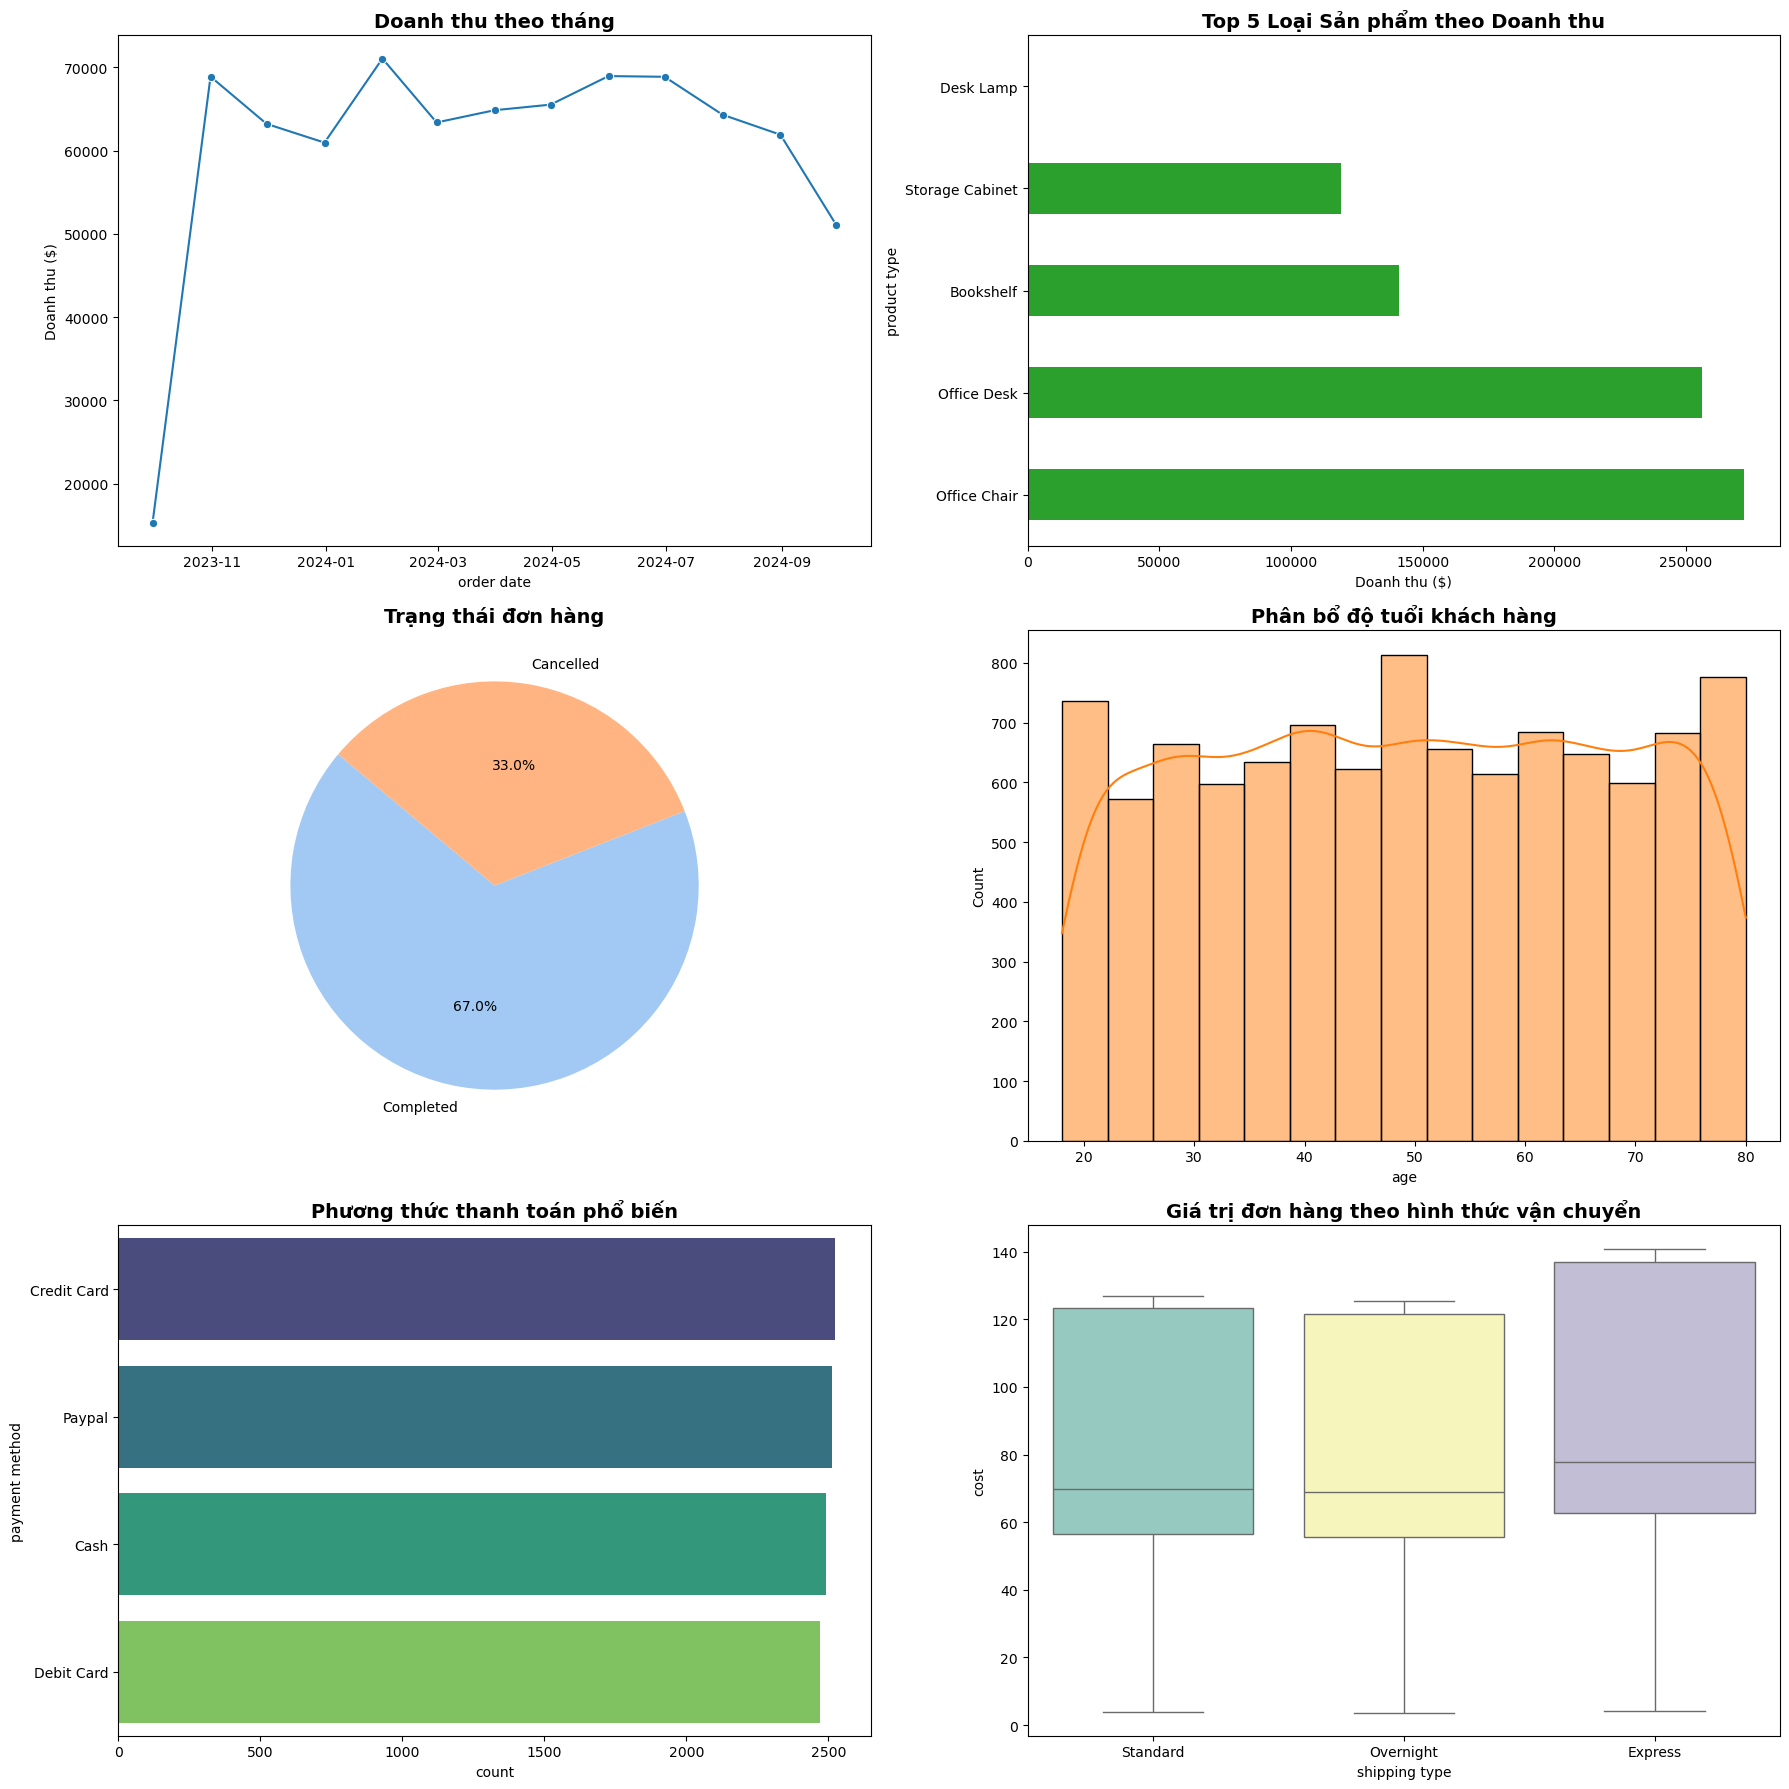

In [50]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
plt.subplots_adjust(hspace=0.4)
# A. Sales Trend (Revenue by Month)
df_monthly = df.set_index('order date').resample('ME')['cost'].sum().reset_index()
sns.lineplot(data=df_monthly, x='order date', y='cost', marker='o', ax=axes[0, 0], color='tab:blue')
axes[0, 0].set_title('Doanh thu theo tháng', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Doanh thu ($)')
# B. Top Products by Revenue
top_products = df.groupby('product type')['cost'].sum().sort_values(ascending=False).head(5)
top_products.plot(kind='barh', ax=axes[0, 1], color='tab:green')
axes[0, 1].set_title('Top 5 Loại Sản phẩm theo Doanh thu', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Doanh thu ($)')
# C. Order Status Distribution
status_counts = df['order status'].value_counts()
axes[1, 0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 0].set_title('Trạng thái đơn hàng', fontsize=14, fontweight='bold')
# D. Customer Age Distribution
sns.histplot(df['age'], bins=15, kde=True, ax=axes[1, 1], color='tab:orange')
axes[1, 1].set_title('Phân bổ độ tuổi khách hàng', fontsize=14, fontweight='bold')
# E. Payment Method Preference
sns.countplot(data=df, y='payment method', hue='payment method', order=df['payment method'].value_counts().index, ax=axes[2, 0], palette='viridis', legend=False)
axes[2, 0].set_title('Phương thức thanh toán phổ biến', fontsize=14, fontweight='bold')
# F. Shipping Method Analysis
sns.boxplot(data=df, x='shipping type', y='cost', hue='shipping type', ax=axes[2, 1], palette='Set3',legend=False)
axes[2, 1].set_title('Giá trị đơn hàng theo hình thức vận chuyển', fontsize=14, fontweight='bold')

plt.tight_layout()

### 1. Phân tích doanh thu & Sản phẩm
- Dòng sản phẩm chủ lực: Office Chair (Ghế văn phòng) và Office Desk (Bàn làm việc) là hai nhóm mang lại doanh thu cao nhất, vượt xa các nhóm còn lại như Bookshelf hay Desk Lamp.

- Xu hướng thời gian: Doanh thu có dấu hiệu đạt đỉnh vào giai đoạn tháng 02/2024 và duy trì ổn định trước khi có xu hướng giảm nhẹ vào cuối quý 3/2024.

### 2. Hành vi khách hàng
- Độ tuổi: Khách hàng trải dài từ 18 đến 80 tuổi, nhưng có sự tập trung đông đảo ở nhóm trung niên (khoảng 45-50 tuổi) và nhóm người cao tuổi (75-80 tuổi).

- Thanh toán & Vận chuyển: Các phương thức thanh toán như Credit Card và Paypal được ưa chuộng nhất. Về vận chuyển, khách hàng sử dụng dịch vụ Express thường có giá trị đơn hàng cao hơn so với các hình thức khác.

### 3. Vấn đề cần lưu ý (Actionable Insights)
- Tỷ lệ hủy đơn (32.6%): Đây là một con số khá cao, cần kiểm tra xem việc hủy đơn đến từ khâu thanh toán bị lỗi hay do thời gian vận chuyển quá lâu.

- Feedback (3.19/5): Mức độ hài lòng ở mức trung bình, cần đi sâu vào phân tích các đơn hàng có điểm 1-2 để cải thiện dịch vụ.